In [187]:
#Load & Understand the Data
import pandas as pd 
df=pd.read_csv("Titanic.csv")

In [188]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [189]:
df.shape

(891, 12)

In [190]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [191]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [192]:
#Drop Unimportant Columns
df.drop(columns=['PassengerId','Name','Ticket'],inplace=True)

In [54]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [193]:
#Check Missing Values
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [181]:
df[['Survived','Pclass','Sex','Embarked','Cabin']] = \
df[['Survived','Pclass','Sex','Embarked','Cabin']].astype('category')
df.dtypes
#Handle Wrong Data Types

PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin          category
Embarked       category
dtype: object

In [194]:
#بعد كده نجيب النسبة المئوية
df.isna().mean(
    
)*100


Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [195]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [196]:
#عازوين نيجب متوسط العمر علي حسب الكلاس و الجنس عشان نملي بيه النل اللي في عمود العمر
# 
Age_Null=df.groupby(['Pclass','Sex'])['Age'].median()
Age_Null

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [197]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [198]:
df['Age'].isna().sum()

np.int64(0)

In [199]:
#هاتلي الـAge بتاعة الناس اللي Pclass = 1.
df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'female'), 'Age'] = \
df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'female'), 'Age'].fillna(32.5)

df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'male'), 'Age'] = \
df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'male'), 'Age'].fillna(36.0)

df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'female'), 'Age'] = \
df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'female'), 'Age'].fillna(28.0)

df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'male'), 'Age'] = \
df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'male'), 'Age'].fillna(30.0)

df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'female'), 'Age'] = \
df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'female'), 'Age'].fillna(21.0)

df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'male'), 'Age'] = \
df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'male'), 'Age'].fillna(25.0)

#هاتلي الصفوف
df[df['Age']==35]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
20,0,2,male,35.0,0,0,26.0000,NaN,S
211,1,2,female,35.0,0,0,21.0000,NaN,S
230,1,1,female,35.0,1,0,83.4750,C83,S
258,1,1,female,35.0,0,0,512.3292,NaN,C
269,1,1,female,35.0,0,0,135.6333,C99,S
279,1,3,female,35.0,1,1,20.2500,NaN,S
363,0,3,male,35.0,0,0,7.0500,NaN,S
383,1,1,female,35.0,1,0,52.0000,NaN,S


In [201]:
#= عدّيلي كام صف Age بتاعتها 35
(df['Age'] == 35).sum()

np.int64(18)

In [218]:
df['Cabin'].describe()

count     204
unique    147
top        G6
freq        4
Name: Cabin, dtype: object

In [219]:
df['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [220]:
#.str[0]
#هنا بتقولي:
#لكل String في العمود، هاتلي أول character.
df['Cabin'].str[0].value_counts()
#
#ده هيقول لنا عدد الركاب الموجود عندنا لكل Deck:

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [221]:
df['Deck'] = df['Cabin'].str[0]

df.groupby('Deck')['Survived'].mean()

Deck
A    0.466667
B    0.744681
C    0.593220
D    0.757576
E    0.750000
F    0.615385
G    0.500000
T    0.000000
Name: Survived, dtype: float64

In [222]:
df['Cabin'].mode()[0]

'B96 B98'

In [228]:
#loc = chatch row
#Handle Missing Values
df['Cabin']=df['Cabin'].fillna(df['Cabin'].str[0].value_counts().idxmax())

In [224]:
#value_counts() → بيقولك كل Deck كام شخص
#idxmin() → بيقولك اسم الـDeck الأقل
#min() → بيقولك عدد الأشخاص في أقل Deck
df['Deck'].str[0].value_counts()

Deck
C    746
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [229]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
Deck        0
dtype: int64

In [226]:
#هاتلي الـAge بتاعة الناس اللي Pclass = 1.
df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'female'), 'Age'] = \
df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'female'), 'Age'].fillna(32.5)

df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'male'), 'Age'] = \
df.loc[(df['Pclass'] == 1) & (df['Sex'] == 'male'), 'Age'].fillna(36.0)

df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'female'), 'Age'] = \
df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'female'), 'Age'].fillna(28.0)

df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'male'), 'Age'] = \
df.loc[(df['Pclass'] == 2) & (df['Sex'] == 'male'), 'Age'].fillna(30.0)

df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'female'), 'Age'] = \
df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'female'), 'Age'].fillna(21.0)

df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'male'), 'Age'] = \
df.loc[(df['Pclass'] == 3) & (df['Sex'] == 'male'), 'Age'].fillna(25.0)

In [227]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      0
Deck          0
dtype: int64

In [93]:
df.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp          int64
Parch          int64
Fare         float64
Cabin       category
Embarked    category
Deck             str
dtype: object

In [94]:
df['Embarked'].describe()

count     889
unique      3
top         S
freq      644
Name: Embarked, dtype: object

In [95]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: category
Categories (3, str): ['C', 'Q', 'S']

In [100]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [207]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].value_counts().idxmin())
#Handle Missing Values

In [102]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
Deck        0
dtype: int64

In [109]:
#Check Outliers metode 1
df.describe( )

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,28.969327,0.523008,0.381594,32.204208
std,13.245607,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.910400
50%,26.000000,0.000000,0.000000,14.454200
75%,36.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


<Axes: >

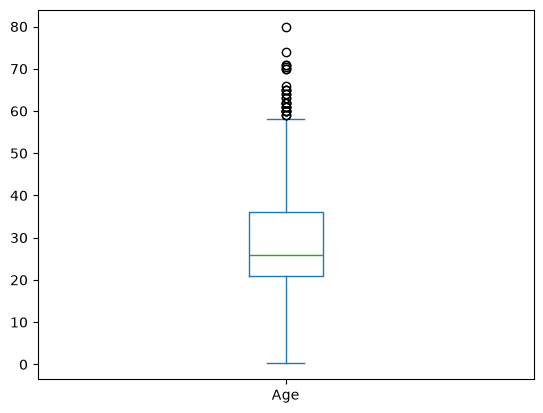

In [105]:
##Check Outliers metode 2

df['Age'].plot(kind='box')


In [208]:
#Check Outliers metode 3 IQR
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)
potential_outliers=df[(df['Age']<lower_bound)|(df['Age']>upper_bound)]
#لو عايزة تشوفي الـAge نفسها فقط:
potential_outliers['Age']


7       2.00
11     58.00
15     55.00
16      2.00
33     66.00
       ...  
827     1.00
829    62.00
831     0.83
851    74.00
879    56.00
Name: Age, Length: 66, dtype: float64

In [ ]:
#ولو عايزة تعرفي عددهم:
len(potential_outliers)
potential_outliers.shape[0]
#
#potential_outliers.shape[0]
#Check Outliers


28

In [209]:
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)
#Check Outliers


Q1 = 22.0
Q3 = 35.0
IQR = 13.0
Lower Bound = 2.5
Upper Bound = 54.5


<Axes: ylabel='Frequency'>

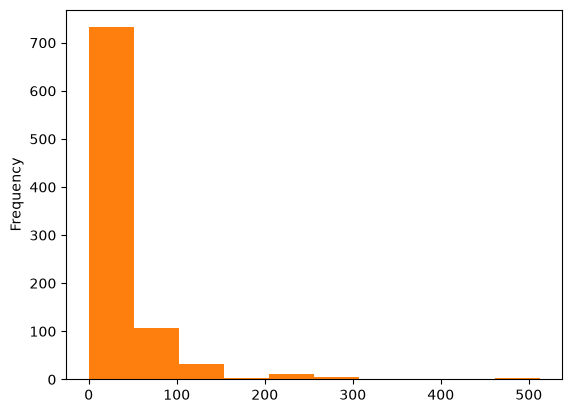

In [ ]:
#Check Outliers
df['Age'].plot(kind='hist')
df['Fare'].plot(kind='hist')

In [135]:
Check_outliers=['Fare','Parch','SibSp','Age']
Check_outliers

['Fare', 'Parch', 'SibSp', 'Age']

In [210]:
for col in Check_outliers:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-(1.5*IQR)
    upper_bound=Q3+(1.5*IQR)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(col)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("--------------------")


Fare
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Outliers: 116
--------------------
Parch
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers: 213
--------------------
SibSp
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 46
--------------------
Age
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 66
--------------------


In [137]:
##Handle Outliers
#case1 remove
#df = df[
#    (df['Age'] >= lower_bound) &
#    (df['Age'] <= upper_bound)
#]
#case2 cap
#df['Age'] = df['Age'].clip(
#    lower=lower_bound,
#    upper=upper_bound
#)
#case3 Transform
#import numpy as np
#
#df['Fare_log'] = np.log1p(df['Fare'])


In [211]:
##Handle Outliers
#case2 cap
#df['Age'] = df['Age'].clip(
#    lower=lower_bound,
#    upper=upper_bound
#)

df.loc[df['Fare'] < lower_bound, 'Fare'] = lower_bound
df.loc[df['Fare'] > upper_bound, 'Fare'] = upper_bound
#df['Fare']=df['Fare'].replace(df['Fare'] > upper_bound)

<Axes: >

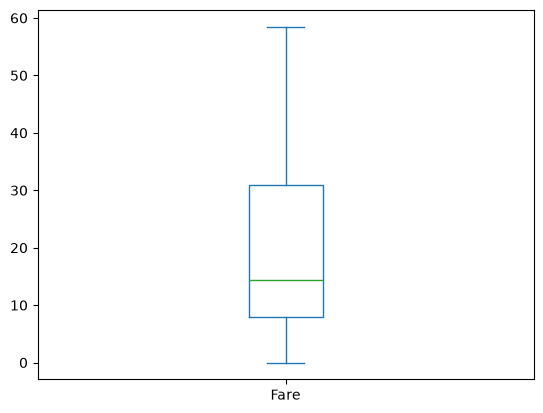

In [174]:
df['Fare'].plot(kind='box')


In [177]:
df['Age'].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

<Axes: >

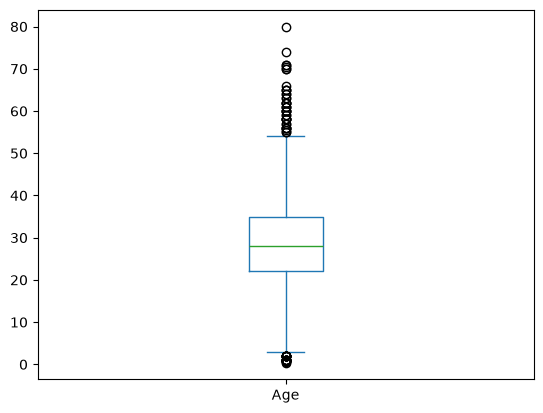

In [212]:
df['Age'].plot(kind='box')


In [213]:
#Check Duplicates

df.duplicated().sum()

np.int64(111)

In [ ]:
df[df.duplicated()]
#Check Duplicates


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Deck
47,1,3,female,28.0,0,0,7.7500,C,Q,C
76,0,3,male,28.0,0,0,7.8958,C,S,C
77,0,3,male,28.0,0,0,8.0500,C,S,C
87,0,3,male,28.0,0,0,8.0500,C,S,C
95,0,3,male,28.0,0,0,8.0500,C,S,C
...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,C,S,C
877,0,3,male,19.0,0,0,7.8958,C,S,C
878,0,3,male,28.0,0,0,7.8958,C,S,C
884,0,3,male,25.0,0,0,7.0500,C,S,C


In [230]:
df['Cabin'].isnull().sum()

np.int64(0)

In [232]:
df = df.drop_duplicates()

In [233]:
df.duplicated().sum()

np.int64(0)

In [234]:
df.shape


(780, 10)